In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
csv_file_path = 'RawData/Press_1027/2026-06-12_12-59-23_6Forces_40x10.csv'

In [41]:
try:
    df = pd.read_csv(csv_file_path)
    print("CSV file loaded successfully!")
except FileNotFoundError:
    print(f"Error: The file at '{csv_file_path}' was not found. Please check the path.")
except Exception as e:
    print(f"An error occurred while loading the CSV: {e}")

CSV file loaded successfully!


In [42]:
df.shape

(48001, 219)

In [43]:
df.head()

,row_type,measurement_index,target_x_mm,target_y_mm,target_force_N,actual_x_mm,actual_y_mm,position_time_s,actual_force_N,force_time_s,...,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207,eit_time_s
0,baseline,NaN,NaN,NaN,NaN,NaN,NaN,0.267163,NaN,NaN,...,0.002562,0.001791,0.004264,0.004386,0.004999,0.005152,0.005979,0.000605,0.000869,0.267163
1,baseline,1.0,60.923077,22.772080,1.5,60.92,22.77,17.802742,0.0000,NaN,...,0.002479,0.001781,0.004307,0.004321,0.004789,0.005184,0.006035,0.000651,0.000845,18.003346
2,contact,1.0,60.923077,22.772080,1.5,60.92,22.77,17.802742,1.5463,25.026540,...,0.002606,0.001786,0.004551,0.004741,0.005212,0.005104,0.006022,0.000914,0.001287,26.225003
3,baseline,2.0,67.384615,24.521368,0.5,67.38,24.52,28.118621,0.0000,NaN,...,0.002444,0.001818,0.004443,0.004577,0.005094,0.005294,0.006054,0.000758,0.001010,28.172027
4,contact,2.0,67.384615,24.521368,0.5,67.38,24.52,28.118621,0.5346,32.071973,...,0.002512,0.001751,0.004405,0.004348,0.005070,0.004513,0.005197,0.000590,0.000871,33.149461


In [44]:
df = df.iloc[1:].reset_index(drop=True)
df.shape

(48000, 219)

In [45]:
df['row_type'].value_counts()

row_type
baseline    24000
contact     24000
Name: count, dtype: int64

In [46]:
df.loc[:, 'target_x_mm'] = df['target_x_mm'].values - 48
df.loc[:, 'target_y_mm'] = df['target_y_mm'].values - 9

In [47]:
df['target_y_mm'].describe()
df['target_x_mm'].describe()

count    48000.000000
mean        31.500000
std         18.647219
min          0.000000
25%         15.750000
50%         31.500000
75%         47.250000
max         63.000000
Name: target_x_mm, dtype: float64

In [48]:
cols_to_exclude = ['target_force_N', 'actual_x_mm', 'actual_y_mm', 'position_time_s', 'force_time_s', 'eit_time_s', 'measurement_index']
df = df.drop(columns=cols_to_exclude, errors='ignore')
df.head()

,row_type,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,baseline,12.923077,13.772080,0.0000,0.03831,0.02446,0.01520,0.01144,0.000707,0.004167,...,0.001911,0.002479,0.001781,0.004307,0.004321,0.004789,0.005184,0.006035,0.000651,0.000845
1,contact,12.923077,13.772080,1.5463,0.03835,0.02453,0.01528,0.01148,0.000772,0.004400,...,0.002188,0.002606,0.001786,0.004551,0.004741,0.005212,0.005104,0.006022,0.000914,0.001287
2,baseline,19.384615,15.521368,0.0000,0.03833,0.02467,0.01522,0.01141,0.000471,0.004085,...,0.001964,0.002444,0.001818,0.004443,0.004577,0.005094,0.005294,0.006054,0.000758,0.001010
3,contact,19.384615,15.521368,0.5346,0.03819,0.02434,0.01503,0.01138,0.000612,0.004161,...,0.001896,0.002512,0.001751,0.004405,0.004348,0.005070,0.004513,0.005197,0.000590,0.000871
4,baseline,17.769231,15.561254,0.0000,0.03825,0.02462,0.01525,0.01153,0.000640,0.004137,...,0.002047,0.002556,0.001696,0.004294,0.004396,0.004993,0.005349,0.006218,0.000754,0.001044


In [49]:
df1 = df.drop(columns=['target_x_mm', 'target_y_mm', 'actual_force_N'])
df1.columns

Index(['row_type', 'eit_0', 'eit_1', 'eit_2', 'eit_3', 'eit_4', 'eit_5',
       'eit_6', 'eit_7', 'eit_8',
       ...
       'eit_198', 'eit_199', 'eit_200', 'eit_201', 'eit_202', 'eit_203',
       'eit_204', 'eit_205', 'eit_206', 'eit_207'],
      dtype='object', length=209)

In [50]:
# Identify EIT columns from the current df
eit_columns = [col for col in df.columns if col.startswith('eit_')]

# Separate baseline and contact rows, ensuring their indices are reset for direct alignment
df_baseline = df[df['row_type'] == 'baseline'].reset_index(drop=True)
df_contact = df[df['row_type'] == 'contact'].reset_index(drop=True)

# Perform the subtraction of EIT values: contact_eit - baseline_eit
# Using .values for efficient element-wise operation, also handles potential SettingWithCopyWarning
df_contact.loc[:, eit_columns] = df_contact[eit_columns].values - df_baseline[eit_columns].values

# Update df to contain only the processed contact rows and drop the 'row_type' column
df_filtered = df_contact.drop(columns=['row_type']).copy()

# Display the head of the transformed DataFrame for verification
df_filtered.head()

,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,12.923077,13.772080,1.5463,0.00004,0.00007,0.00008,0.00004,0.000065,0.000233,0.000045,...,0.000277,0.000127,0.000005,0.000244,0.000420,0.000423,-0.000080,-0.000013,0.000263,0.000442
1,19.384615,15.521368,0.5346,-0.00014,-0.00033,-0.00019,-0.00003,0.000141,0.000076,-0.000047,...,-0.000068,0.000068,-0.000067,-0.000038,-0.000229,-0.000024,-0.000781,-0.000857,-0.000167,-0.000139
2,17.769231,15.561254,1.5631,-0.00007,-0.00012,-0.00009,-0.00028,0.000065,0.000087,-0.000135,...,-0.000015,-0.000058,0.000154,0.000109,0.000086,0.000023,-0.000964,-0.001123,0.000015,-0.000112
3,16.153846,11.829060,0.5028,-0.00002,-0.00010,-0.00005,-0.00012,-0.000040,-0.000034,-0.000254,...,-0.000007,0.000051,-0.000082,-0.000083,-0.000037,-0.000056,-0.000561,-0.000437,0.000256,0.000199
4,35.538462,8.125356,4.0974,0.00132,0.00023,0.00000,-0.00046,0.000951,-0.000014,-0.000431,...,0.000009,0.000169,0.000821,0.000008,-0.000363,-0.000373,-0.000367,-0.000253,-0.000166,-0.000137


In [51]:
df_filtered.shape

(24000, 211)

In [52]:
# Shuffling the filtered dataframe
df_shuffled = df_filtered.sample(frac=1, random_state=5).reset_index(drop=True)

print(f"DataFrame sliced (original: {len(df)}, filtered: {len(df_filtered)})")
print("DataFrame shuffled successfully. Displaying first 5 rows of shuffled data:")
df_shuffled.head()

DataFrame sliced (original: 48000, filtered: 24000)
DataFrame shuffled successfully. Displaying first 5 rows of shuffled data:


,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
0,43.615385,16.615385,1.3083,0.00161,0.00121,0.00134,0.00043,0.000243,-0.000104,0.000244,...,0.002956,-0.000684,-0.000165,-0.000004,0.000029,-0.000012,0.000209,-0.000323,-0.000054,-0.000080
1,9.692308,4.170940,1.7638,-0.00032,-0.00064,-0.00070,0.00029,0.000492,-0.000256,-0.000296,...,0.000516,-0.000948,0.000043,0.000557,0.000499,0.000877,0.002725,0.004088,0.004957,0.004835
2,51.692308,13.088319,0.7783,0.00163,0.00087,0.00056,-0.00075,-0.000471,0.001067,0.000991,...,0.001395,-0.000365,0.000634,0.000526,0.000461,0.000174,0.000104,-0.000434,-0.000265,-0.000217
3,4.846154,4.085470,5.5976,0.00067,0.00048,0.00028,0.00014,-0.000053,-0.000043,0.000191,...,0.000224,0.000087,-0.000140,0.001415,0.001345,0.001698,0.002540,0.002526,0.003340,0.003276
4,40.384615,1.282051,1.0704,-0.00118,-0.00112,-0.00200,-0.00214,-0.001477,-0.000201,-0.000573,...,-0.000775,0.001014,-0.000105,-0.000038,-0.000299,-0.000102,-0.000536,-0.000224,-0.000371,-0.000161


In [53]:
df_shuffled.describe()

,target_x_mm,target_y_mm,actual_force_N,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
count,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,...,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000,24000.000000
mean,31.500000,9.000000,3.420624,-0.000875,-0.000952,-0.000812,-0.000965,0.000003,0.000010,-0.000042,...,0.000151,0.000244,0.000233,0.000145,0.000128,0.000135,0.000240,0.000328,0.000351,0.000323
std,18.647413,5.120345,1.707302,0.002469,0.002126,0.001934,0.001861,0.000857,0.001071,0.001032,...,0.000830,0.000782,0.000617,0.000948,0.000907,0.000957,0.001258,0.001402,0.001107,0.001081
min,0.000000,0.000000,0.500300,-0.019100,-0.015550,-0.014806,-0.013921,-0.003092,-0.004531,-0.004495,...,-0.004078,-0.001860,-0.001553,-0.004547,-0.008523,-0.007712,-0.003657,-0.005085,-0.002258,-0.002316
25%,15.750000,4.562679,2.121100,-0.001270,-0.001290,-0.001250,-0.001500,-0.000495,-0.000473,-0.000510,...,-0.000273,-0.000172,-0.000076,-0.000266,-0.000283,-0.000294,-0.000302,-0.000276,-0.000191,-0.000188
50%,31.500000,9.000000,3.190550,-0.000440,-0.000510,-0.000450,-0.000530,-0.000053,-0.000044,-0.000085,...,0.000101,0.000078,0.000080,0.000092,0.000045,0.000034,-0.000051,0.000014,0.000087,0.000078
75%,47.250000,13.437322,4.396750,0.000090,-0.000010,0.000070,0.000030,0.000369,0.000398,0.000317,...,0.000502,0.000476,0.000334,0.000498,0.000449,0.000489,0.000388,0.000521,0.000536,0.000494
max,63.000000,18.000000,9.789600,0.009510,0.008210,0.008050,0.007270,0.006906,0.008692,0.008646,...,0.004357,0.007791,0.007728,0.008512,0.008821,0.009009,0.014237,0.014649,0.013387,0.013240


In [54]:
from sklearn.model_selection import train_test_split
X = df_shuffled.drop(columns=['target_x_mm', 'target_y_mm', 'actual_force_N'], axis=1)
Y = df_shuffled[['target_x_mm', 'target_y_mm', 'actual_force_N']]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y,
                                                    test_size=0.2,
                                                    random_state=0)

X_train.shape, X_test.shape

((19200, 208), (4800, 208))

In [55]:
X_train.head()

,eit_0,eit_1,eit_2,eit_3,eit_4,eit_5,eit_6,eit_7,eit_8,eit_9,...,eit_198,eit_199,eit_200,eit_201,eit_202,eit_203,eit_204,eit_205,eit_206,eit_207
15613,-0.00096,-0.00093,-0.00101,-0.00104,-0.000352,0.000286,0.000390,0.000103,-0.000042,-0.000155,...,0.000167,0.000076,0.000122,0.000032,0.000078,0.000124,0.000317,0.001131,0.000439,0.000405
17719,0.00012,-0.00012,-0.00002,-0.00008,-0.000255,0.000565,0.000453,0.000384,0.000891,0.000602,...,0.000317,0.000308,0.000110,0.000943,0.000857,0.001265,0.001699,0.001828,0.002738,0.002700
16235,0.00019,-0.00076,-0.00051,0.00066,-0.000728,0.001197,0.002009,0.002126,0.001677,0.001890,...,0.000426,-0.000260,0.000559,0.001782,0.002229,0.002668,0.001810,0.002457,0.000546,0.000510
467,-0.00061,-0.00302,-0.00131,-0.00233,-0.000424,0.004199,0.004001,0.002980,0.002825,-0.000125,...,0.001066,-0.000780,-0.000092,-0.000637,-0.000480,-0.000272,-0.000183,0.000227,0.000210,0.000264
21093,-0.00056,-0.00018,0.00013,-0.00134,0.001188,-0.002050,-0.001399,-0.001281,-0.000024,0.000461,...,0.000334,0.000268,0.000758,-0.002012,-0.001436,-0.001240,0.000071,0.000891,0.000813,0.000770


In [56]:
Y_train.head()

,target_x_mm,target_y_mm,actual_force_N
15613,17.769231,9.937322,1.1975
17719,6.461538,6.068376,5.5464
16235,22.615385,2.558405,2.4948
467,61.384615,11.350427,3.7417
21093,33.923077,11.641026,1.1376


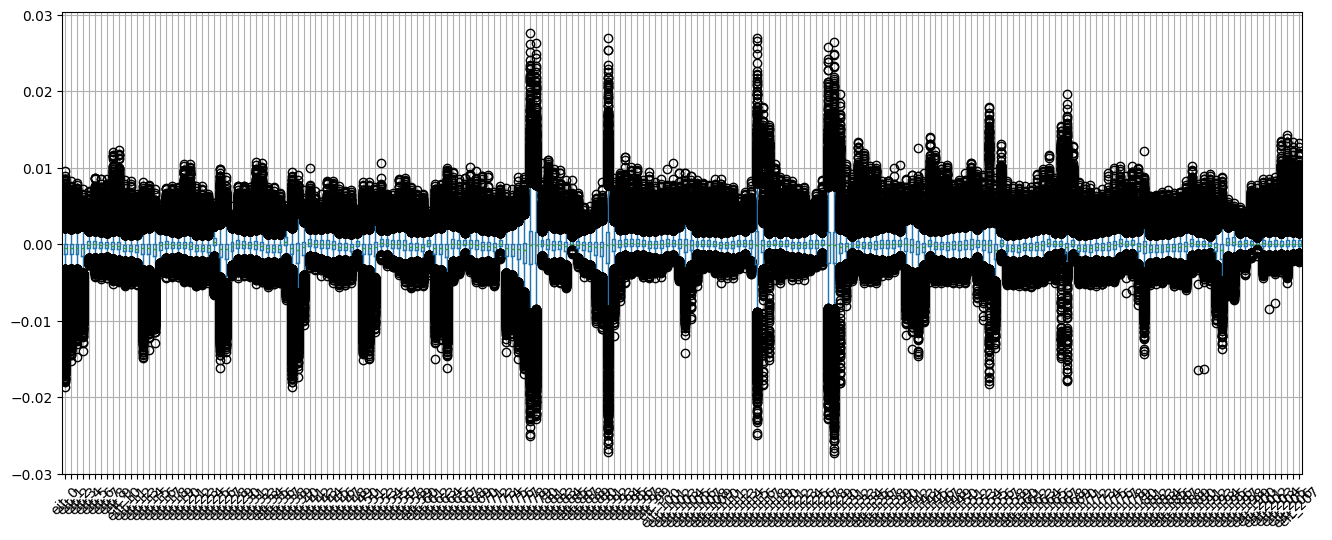

In [57]:
X_train.boxplot(figsize=(16, 6))
plt.xticks(rotation=45)
plt.show()

In [58]:
# Normalize the eit values
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

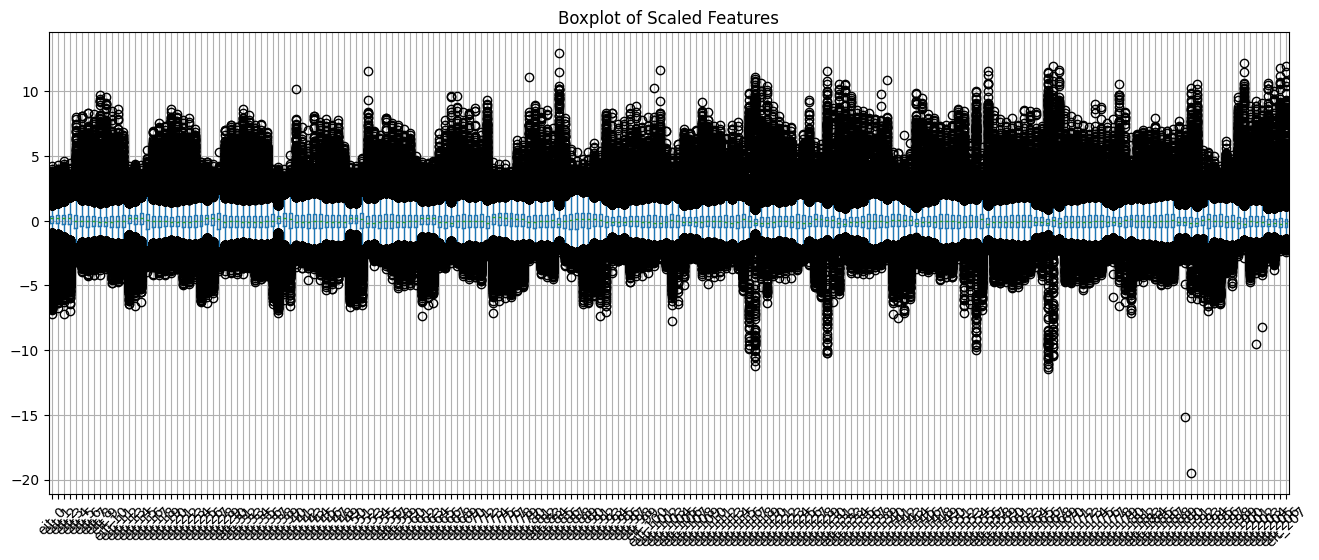

In [59]:
# Convert the scaled numpy array back to a DataFrame to use the boxplot method
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Now plot the boxplot
X_train_scaled_df.boxplot(figsize=(16, 6))
plt.xticks(rotation=45)
plt.title("Boxplot of Scaled Features")
plt.show()

In [60]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3, 208)","[[ 0.07,-5. , 3.43,..., 1.49,-5.86, 2.31], [-0.91, 1.1 ,-0.24,...,-1.16, 1.09,-1.37], [ 0.14,-0.4 , 0.31,..., 0.27,-0.12, 0.07]]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](3,)","[31.66, 9. , 3.42]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,208
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,208
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](208,)","[1002.06, 864.72, 560.17,..., 5.34, 5.18, 4.76]"


In [61]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Make predictions on the scaled test set
y_pred = model.predict(X_test_scaled)

# Calculate metrics
mse = mean_squared_error(Y_test, y_pred, multioutput='raw_values')
r2 = r2_score(Y_test, y_pred, multioutput='raw_values')
rmse = np.sqrt(mse)
mae = mean_absolute_error(Y_test, y_pred, multioutput='raw_values')

# Display the results for each target
target_names = Y.columns
metrics_df = pd.DataFrame({
    'Target': target_names,
    'MAE': mae,
    'RMSE': rmse,
    'R2 Score': r2,

})

print("Model Evaluation Metrics:")
display(metrics_df)

Model Evaluation Metrics:


,Target,MAE,RMSE,R2 Score
0,target_x_mm,6.488588,8.220674,0.805415
1,target_y_mm,2.057305,2.724179,0.719036
2,actual_force_N,1.332777,1.648270,0.079590


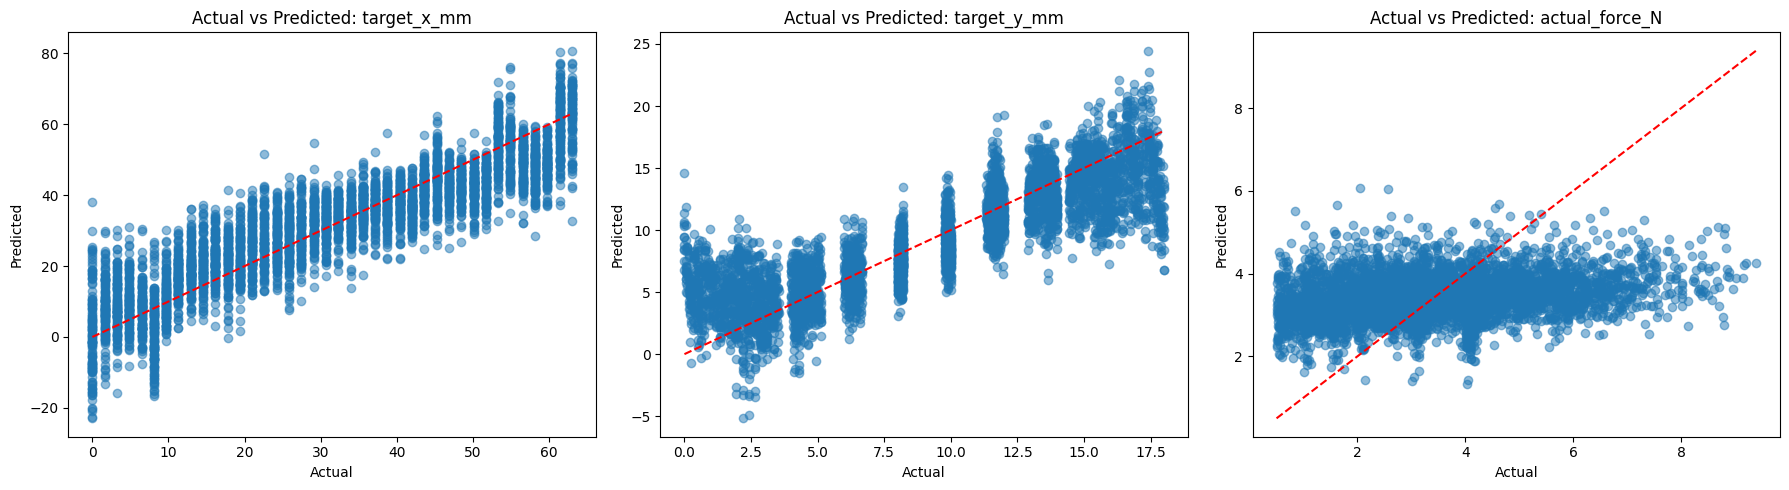

In [62]:
# Optional: Visualize Predictions vs Actual
plt.figure(figsize=(18, 5))

for i, col in enumerate(target_names):
    plt.subplot(1, 3, i+1)
    plt.scatter(Y_test.iloc[:, i], y_pred[:, i], alpha=0.5)
    plt.plot([Y_test.iloc[:, i].min(), Y_test.iloc[:, i].max()],
             [Y_test.iloc[:, i].min(), Y_test.iloc[:, i].max()], 'r--')
    plt.title(f'Actual vs Predicted: {col}')
    plt.xlabel('Actual')
    plt.ylabel('Predicted')

plt.tight_layout()
plt.show()

In [63]:
Y_test['target_x_mm'].describe()

count    4800.000000
mean       30.877740
std        18.637968
min         0.000000
25%        14.538462
50%        30.692308
75%        46.846154
max        63.000000
Name: target_x_mm, dtype: float64

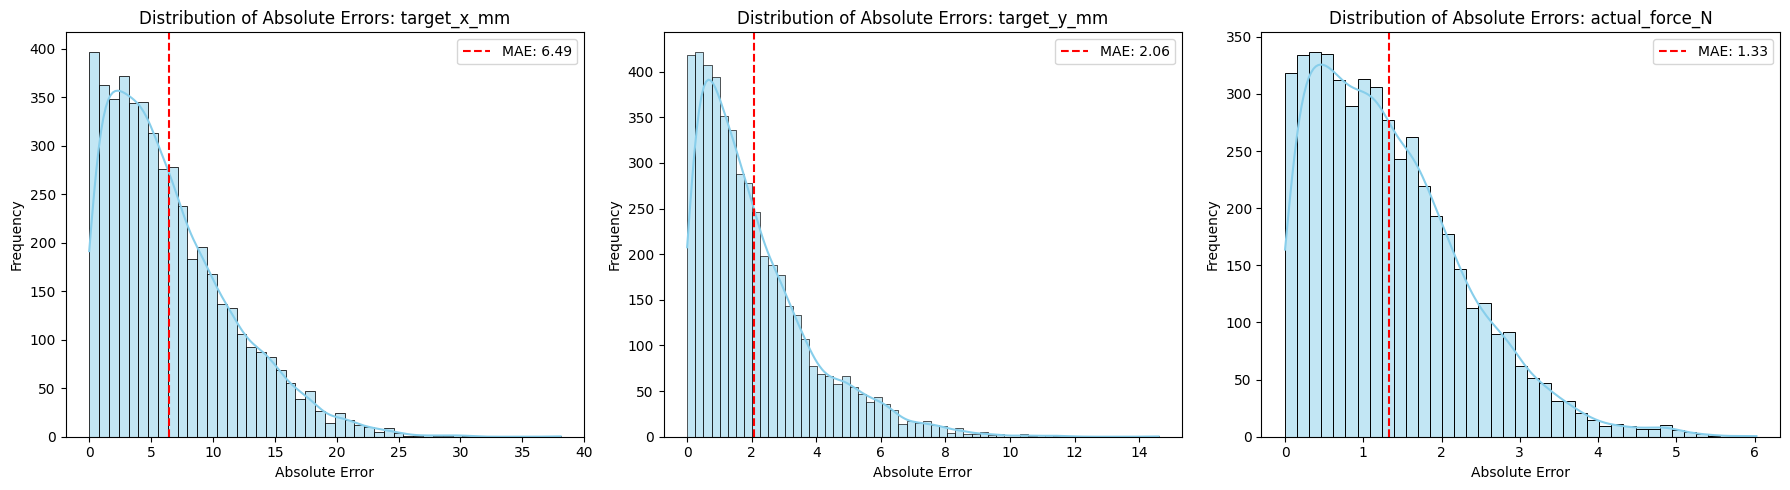

In [64]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate absolute errors for each prediction
absolute_errors = np.abs(Y_test.values - y_pred)

# Create a figure with subplots for each target
plt.figure(figsize=(18, 5))

for i, col in enumerate(target_names):
    plt.subplot(1, 3, i+1)
    sns.histplot(absolute_errors[:, i], kde=True, color='skyblue')
    plt.axvline(metrics_df.loc[i, 'MAE'], color='red', linestyle='--', label=f'MAE: {metrics_df.loc[i, "MAE"]:.2f}')
    plt.title(f'Distribution of Absolute Errors: {col}')
    plt.xlabel('Absolute Error')
    plt.ylabel('Frequency')
    plt.legend()

plt.tight_layout()
plt.show()

In [65]:
actual_x = Y_test['target_x_mm']
actual_y = Y_test['target_y_mm']
predicted_x = y_pred[:, 0]
predicted_y = y_pred[:, 1]

# Calculate Euclidean distance error for (x,y) coordinates
distance_errors = np.sqrt((actual_x - predicted_x)**2 + (actual_y - predicted_y)**2)

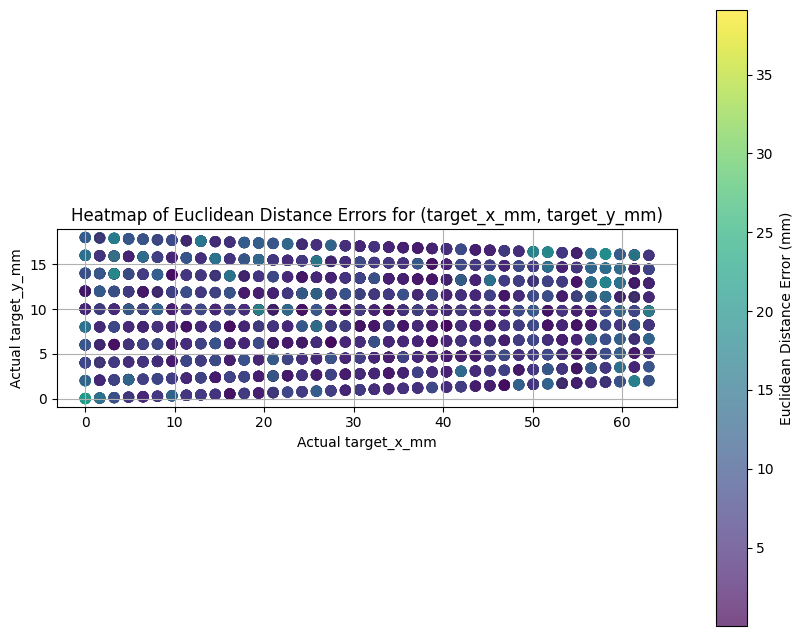

In [66]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(actual_x, actual_y, c=distance_errors, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, label='Euclidean Distance Error (mm)')
plt.title('Heatmap of Euclidean Distance Errors for (target_x_mm, target_y_mm)')
plt.xlabel('Actual target_x_mm')
plt.ylabel('Actual target_y_mm')
plt.gca().set_aspect('equal', adjustable='box') # Set aspect ratio to auto
plt.grid(True)
plt.show()

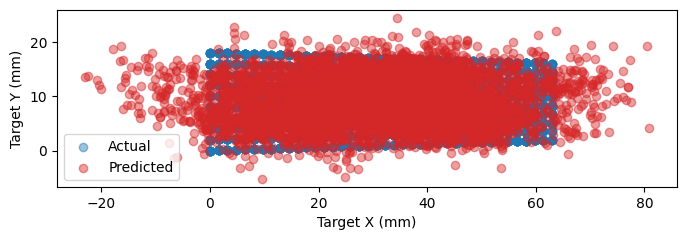

In [74]:
# Compare actual and predicted test positions
plt.figure(figsize=(8, 6))
plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('Target X (mm)')
plt.ylabel('Target Y (mm)')
plt.scatter(Y_test['target_x_mm'], Y_test['target_y_mm'], color='tab:blue', label='Actual', alpha=0.45)
plt.scatter(y_pred[:, 0], y_pred[:, 1], color='tab:red', label='Predicted', alpha=0.45)
plt.legend()
plt.show()

In [67]:
x_errors = np.abs(actual_x - predicted_x)

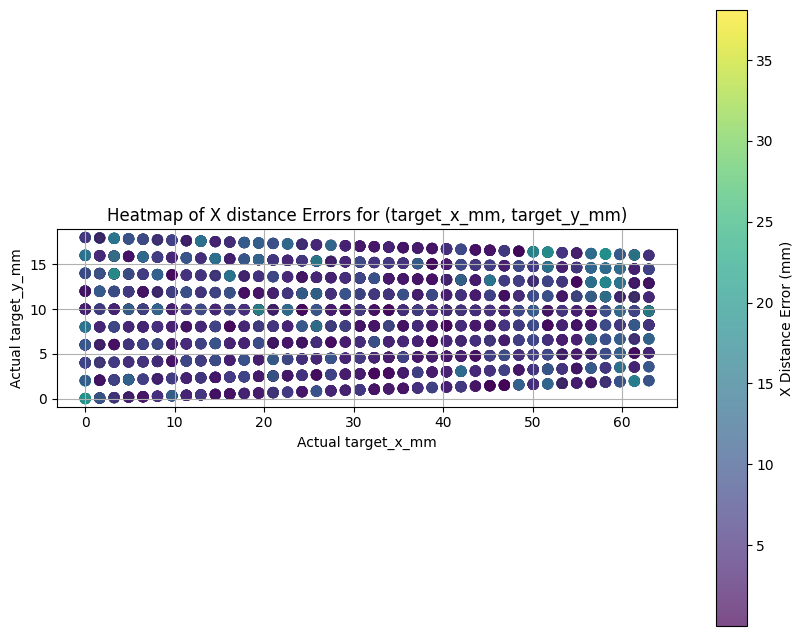

In [68]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(actual_x, actual_y, c=x_errors, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, label='X Distance Error (mm)')
plt.title('Heatmap of X distance Errors for (target_x_mm, target_y_mm)')
plt.xlabel('Actual target_x_mm')
plt.ylabel('Actual target_y_mm')
plt.gca().set_aspect('equal', adjustable='box') # Set aspect ratio to auto
plt.grid(True)
plt.show()

In [69]:
y_errors = np.abs(actual_y - predicted_y)

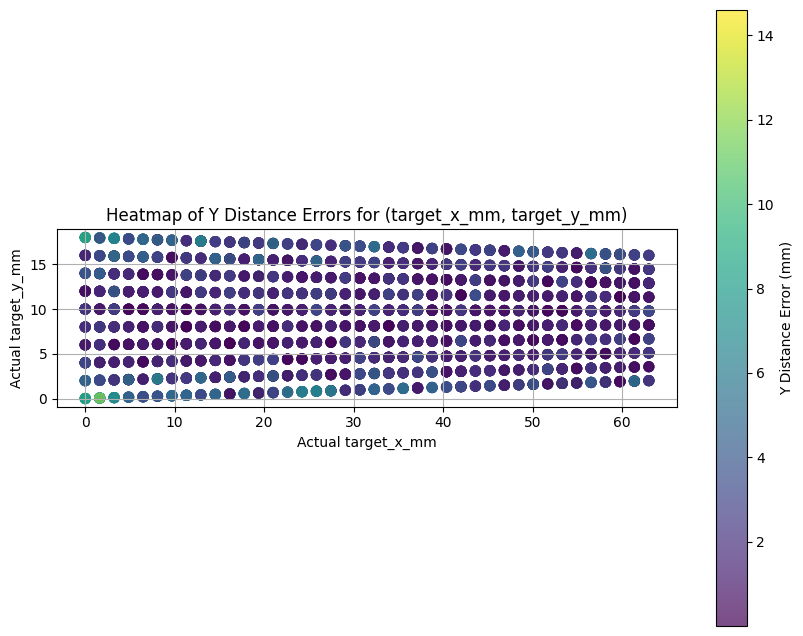

In [70]:
plt.figure(figsize=(10, 8))
scatter = plt.scatter(actual_x, actual_y, c=y_errors, cmap='viridis', s=50, alpha=0.7)
plt.colorbar(scatter, label='Y Distance Error (mm)')
plt.title('Heatmap of Y Distance Errors for (target_x_mm, target_y_mm)')
plt.xlabel('Actual target_x_mm')
plt.ylabel('Actual target_y_mm')
plt.gca().set_aspect('equal', adjustable='box') # Set aspect ratio to auto
plt.grid(True)
plt.show()

In [71]:
condition = (Y_test['target_y_mm'] > 3) & (Y_test['target_y_mm'] < 15) & (Y_test['target_x_mm'] > 0) & (Y_test['target_x_mm'] < 55)

# Filter Y_test and y_pred based on the condition
Y_test_filtered = Y_test[condition]
y_pred_filtered = y_pred[condition.values]

print(f"Original Y_test shape: {Y_test.shape}")
print(f"Filtered Y_test shape: {Y_test_filtered.shape}")

Original Y_test shape: (4800, 3)
Filtered Y_test shape: (2637, 3)


In [72]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

# Calculate metrics for the filtered data
mse_filtered = mean_squared_error(Y_test_filtered, y_pred_filtered, multioutput='raw_values')
r2_filtered = r2_score(Y_test_filtered, y_pred_filtered, multioutput='raw_values')
rmse_filtered = np.sqrt(mse_filtered)
mae_filtered = mean_absolute_error(Y_test_filtered, y_pred_filtered, multioutput='raw_values')

# Display the results for each target in a DataFrame
target_names = Y_test_filtered.columns
metrics_df_filtered = pd.DataFrame({
    'Target': target_names,
    'MSE': mse_filtered,
    'RMSE': rmse_filtered,
    'R2 Score': r2_filtered,
    'MAE': mae_filtered
})

print("Model Evaluation Metrics for Y_test['target_y_mm'] < 65mm:")
display(metrics_df_filtered)

Model Evaluation Metrics for Y_test['target_y_mm'] < 65mm:


,Target,MSE,RMSE,R2 Score,MAE
0,target_x_mm,55.516250,7.450923,0.782602,5.890413
1,target_y_mm,3.406395,1.845642,0.701137,1.465840
2,actual_force_N,2.657609,1.630217,0.074941,1.316475


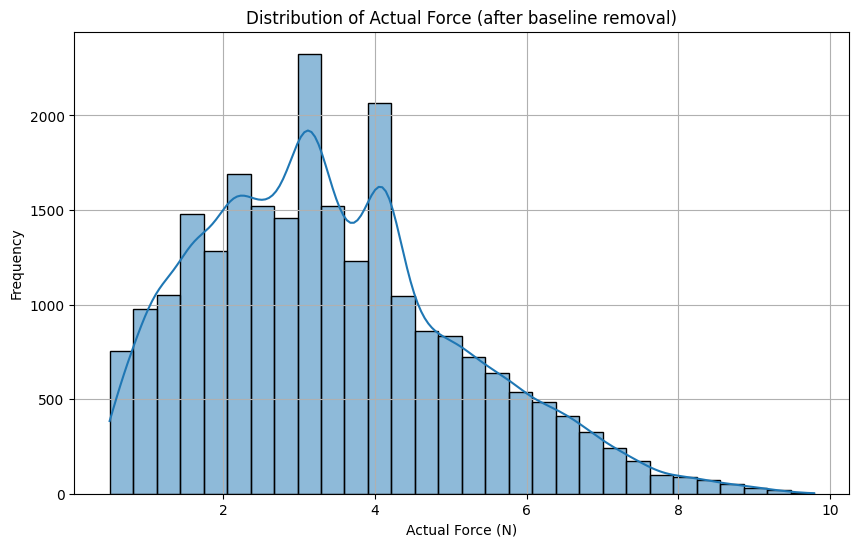

In [73]:
plt.figure(figsize=(10, 6))
sns.histplot(df_filtered['actual_force_N'], kde=True, bins=30)
plt.title('Distribution of Actual Force (after baseline removal)')
plt.xlabel('Actual Force (N)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()